In [108]:
# load the finished SROIE modeling table for lightweight classification experiments
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

model_df_path = PROJECT_ROOT / "outputs" / "sroie_model_df.csv"
sroie_model_df = pd.read_csv(model_df_path)

print(model_df_path)
print(sroie_model_df.shape)
display(sroie_model_df.head())

/Users/quentin/Documents/Computer/School/CMU/Spring_2026/38616/Gated-Risk-MCP/outputs/sroie_model_df.csv
(712, 48)


,doc_id,dataset,split,img_width,img_height,n_tokens,n_boxes,ocr_char_count,ocr_word_count,company_present,...,company_hard,date_hard,address_hard,total_hard,low_ocr_support,proxy_risk_score,strict_high_risk,review_worthy,proxy_verify,proxy_high_risk
0,X00016469612,SROIE,train,463.0,1013.0,44,44,441,84,True,...,True,False,False,False,False,1,0,1,False,False
1,X00016469619,SROIE,train,439.0,1004.0,48,48,637,102,True,...,False,False,False,False,False,0,0,0,False,False
2,X00016469620,SROIE,train,459.0,949.0,54,54,668,121,True,...,True,False,False,False,False,1,0,1,False,False
3,X00016469622,SROIE,train,461.0,933.0,60,60,525,105,True,...,False,False,False,False,False,0,0,0,False,False
4,X00016469623,SROIE,train,463.0,1026.0,61,61,735,142,True,...,False,False,False,False,False,0,0,0,False,False


In [109]:
# define the SROIE target and feature set for lightweight classification experiments
TARGET_COL = "review_worthy"

FEATURE_COLS = [
    "n_tokens",
    "n_boxes",
    "ocr_char_count",
    "ocr_word_count",
    "company_len",
    "date_len",
    "address_len",
    "total_len",
    "n_amount_like_tokens",
    "n_date_like_tokens",
    "token_box_ratio",
    "amount_token_ratio",
    "date_token_ratio",
    "avg_token_len",
    "avg_words_per_token",
    "anchors_present_count",
    "fields_present_count",
    "aspect_ratio",
    "has_total_anchor",
    "has_date_anchor",
    "has_cash_anchor",
]

X = sroie_model_df[FEATURE_COLS].copy()
y = sroie_model_df[TARGET_COL].astype(int).copy()

print("target:", TARGET_COL)
print("positive rate:", y.mean())
display(X.head())

target: review_worthy
positive rate: 0.13764044943820225


,n_tokens,n_boxes,ocr_char_count,ocr_word_count,company_len,date_len,address_len,total_len,n_amount_like_tokens,n_date_like_tokens,...,amount_token_ratio,date_token_ratio,avg_token_len,avg_words_per_token,anchors_present_count,fields_present_count,aspect_ratio,has_total_anchor,has_date_anchor,has_cash_anchor
0,44,44,441,84,31,10,70,4,7,0,...,0.159091,0.000000,10.022727,1.909091,3,4,0.457058,True,True,True
1,48,48,637,102,22,10,63,5,11,0,...,0.229167,0.000000,13.270833,2.125000,2,4,0.437251,True,False,True
2,54,54,668,121,25,8,118,5,12,0,...,0.222222,0.000000,12.370370,2.240741,2,4,0.483667,True,False,True
3,60,60,525,105,19,10,44,5,16,1,...,0.266667,0.016667,8.750000,1.750000,3,4,0.494105,True,True,True
4,61,61,735,142,21,8,116,5,15,0,...,0.245902,0.000000,12.049180,2.327869,2,4,0.451267,True,False,True


In [110]:
# split the data once so all lightweight models are compared on the same train/test partition
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=60,
    stratify=y,
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(569, 21) (143, 21)
0.13708260105448156 0.13986013986013987


In [111]:
# define a shared evaluation helper for all lightweight models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_binary_model(model_name, model, X_train, X_test, y_train, y_test, threshold=0.5):
    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    y_pred = (y_score >= threshold).astype(int)

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pred_verify_rate": y_pred.mean(),
    }

In [112]:
# train four lightweight baselines: logistic regression, shallow tree, random forest, and gradient boosting
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

results = []

log_reg = LogisticRegression(max_iter=5000, random_state=60)
tree = DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=60)
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=60,
)
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=60,
)

results.append(evaluate_binary_model("logistic_regression", log_reg, X_train, X_test, y_train, y_test))
results.append(evaluate_binary_model("decision_tree_depth4", tree, X_train, X_test, y_train, y_test))
results.append(evaluate_binary_model("random_forest_depth6", rf, X_train, X_test, y_train, y_test))
results.append(evaluate_binary_model("gradient_boosting", gb, X_train, X_test, y_train, y_test))

results_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
display(results_df)

,model,accuracy,precision,recall,f1,roc_auc,pred_verify_rate
0,gradient_boosting,0.951049,1.000000,0.65,0.787879,0.882927,0.090909
1,logistic_regression,0.944056,1.000000,0.60,0.750000,0.840650,0.083916
2,random_forest_depth6,0.916084,0.785714,0.55,0.647059,0.860976,0.097902
3,decision_tree_depth4,0.741259,0.292683,0.60,0.393443,0.788618,0.286713


In [113]:
# define the best known rule baseline for the current SROIE target and compare it to learned models
if TARGET_COL == "strict_high_risk":
    rule_baseline_name = "verify_if_two_or_more_hard_flags"
    rule_pred = (
        sroie_model_df.loc[X_test.index, ["company_hard", "date_hard", "address_hard", "total_hard"]]
        .sum(axis=1) >= 2
    ).astype(int)
elif TARGET_COL == "review_worthy":
    rule_baseline_name = "review_rule_v3_address_or_company_or_date_total_pair"
    rule_pred = (
        sroie_model_df.loc[X_test.index, "address_hard"]
        | sroie_model_df.loc[X_test.index, "company_hard"]
        | (
            sroie_model_df.loc[X_test.index, ["date_hard", "total_hard"]].sum(axis=1) >= 2
        )
    ).astype(int)
else:
    raise ValueError(f"unsupported target: {TARGET_COL}")

rule_baseline_metrics = pd.DataFrame([
    {
        "model": rule_baseline_name,
        "accuracy": accuracy_score(y_test, rule_pred),
        "precision": precision_score(y_test, rule_pred, zero_division=0),
        "recall": recall_score(y_test, rule_pred, zero_division=0),
        "f1": f1_score(y_test, rule_pred, zero_division=0),
        "roc_auc": float("nan"),
        "pred_verify_rate": rule_pred.mean(),
    }
])

model_vs_rule_df = pd.concat(
    [rule_baseline_metrics, results_df],
    ignore_index=True,
).sort_values(
    ["f1", "recall", "precision", "accuracy"],
    ascending=False,
).reset_index(drop=True)

display(rule_baseline_metrics)
display(model_vs_rule_df)

,model,accuracy,precision,recall,f1,roc_auc,pred_verify_rate
0,review_rule_v3_address_or_company_or_date_tota...,1.0,1.0,1.0,1.0,NaN,0.13986


,model,accuracy,precision,recall,f1,roc_auc,pred_verify_rate
0,review_rule_v3_address_or_company_or_date_tota...,1.000000,1.000000,1.00,1.000000,NaN,0.139860
1,gradient_boosting,0.951049,1.000000,0.65,0.787879,0.882927,0.090909
2,logistic_regression,0.944056,1.000000,0.60,0.750000,0.840650,0.083916
3,random_forest_depth6,0.916084,0.785714,0.55,0.647059,0.860976,0.097902
4,decision_tree_depth4,0.741259,0.292683,0.60,0.393443,0.788618,0.286713


In [114]:
# identify the best learned model separately from the best overall result
model_map = {
    "logistic_regression": log_reg,
    "decision_tree_depth4": tree,
    "random_forest_depth6": rf,
    "gradient_boosting": gb,
}

best_learned_model_name = results_df.iloc[0]["model"]
best_learned_model = model_map[best_learned_model_name]

print("best learned model:", best_learned_model_name)
print("best overall comparison:")
display(model_vs_rule_df.head(5))

best learned model: gradient_boosting
best overall comparison:


,model,accuracy,precision,recall,f1,roc_auc,pred_verify_rate
0,review_rule_v3_address_or_company_or_date_tota...,1.000000,1.000000,1.00,1.000000,NaN,0.139860
1,gradient_boosting,0.951049,1.000000,0.65,0.787879,0.882927,0.090909
2,logistic_regression,0.944056,1.000000,0.60,0.750000,0.840650,0.083916
3,random_forest_depth6,0.916084,0.785714,0.55,0.647059,0.860976,0.097902
4,decision_tree_depth4,0.741259,0.292683,0.60,0.393443,0.788618,0.286713


In [115]:
model_vs_rule_df = pd.concat(
    [rule_baseline_metrics, results_df],
    ignore_index=True,
).sort_values(
    ["f1", "recall", "precision", "accuracy"],
    ascending=False,
).reset_index(drop=True)

display(model_vs_rule_df)

,model,accuracy,precision,recall,f1,roc_auc,pred_verify_rate
0,review_rule_v3_address_or_company_or_date_tota...,1.000000,1.000000,1.00,1.000000,NaN,0.139860
1,gradient_boosting,0.951049,1.000000,0.65,0.787879,0.882927,0.090909
2,logistic_regression,0.944056,1.000000,0.60,0.750000,0.840650,0.083916
3,random_forest_depth6,0.916084,0.785714,0.55,0.647059,0.860976,0.097902
4,decision_tree_depth4,0.741259,0.292683,0.60,0.393443,0.788618,0.286713


In [116]:
# inspect feature importance for the selected best learned tree-based model when available
best_learned_model.fit(X_train, y_train)

if hasattr(best_learned_model, "feature_importances_"):
    feature_importance_df = pd.DataFrame({
        "feature": FEATURE_COLS,
        "importance": best_learned_model.feature_importances_,
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    print(best_learned_model_name)
    display(feature_importance_df)
else:
    print(f"{best_learned_model_name} does not expose feature importances.")

gradient_boosting


,feature,importance
0,address_len,0.539333
1,aspect_ratio,0.077790
2,avg_token_len,0.063172
3,ocr_word_count,0.060564
4,ocr_char_count,0.053520
5,date_token_ratio,0.042471
6,avg_words_per_token,0.042334
7,amount_token_ratio,0.039972
8,n_amount_like_tokens,0.023372
9,n_boxes,0.020214


In [117]:
# inspect a few predicted high-risk receipts from the best learned model
if hasattr(best_learned_model, "predict_proba"):
    best_scores = best_learned_model.predict_proba(X_test)[:, 1]
else:
    best_scores = best_learned_model.decision_function(X_test)

pred_df = X_test.copy()
pred_df["doc_id"] = sroie_model_df.loc[X_test.index, "doc_id"]
pred_df["y_true"] = y_test
pred_df["pred_score"] = best_scores

print(best_learned_model_name)
display(pred_df.sort_values("pred_score", ascending=False).head(15))

gradient_boosting


,n_tokens,n_boxes,ocr_char_count,ocr_word_count,company_len,date_len,address_len,total_len,n_amount_like_tokens,n_date_like_tokens,...,avg_words_per_token,anchors_present_count,fields_present_count,aspect_ratio,has_total_anchor,has_date_anchor,has_cash_anchor,doc_id,y_true,pred_score
108,62,62,596,112,0,0,0,0,18,0,...,1.806452,2,0,0.577567,True,False,True,X51005605284(3),1,0.997207
172,0,0,0,0,0,0,0,0,0,0,...,0.000000,0,0,0.405863,False,False,False,X51005685357(2),1,0.990412
301,58,58,556,106,0,0,0,0,18,0,...,1.827586,2,0,0.410569,True,False,True,X51006332649(1),1,0.987384
316,52,52,502,105,0,0,0,0,13,0,...,2.019231,2,0,0.475222,True,False,True,X51006335314(3),1,0.980803
58,34,34,523,93,0,0,0,0,9,0,...,2.735294,2,0,0.706806,True,False,True,X51005442378(1),1,0.973593
312,40,40,595,101,0,0,0,0,10,0,...,2.525000,2,0,0.376550,True,False,True,X51006334926(3),1,0.972331
166,64,64,590,114,0,0,0,0,18,0,...,1.781250,3,0,0.484691,True,True,True,X51005677339(2),1,0.971702
303,46,46,739,125,0,0,0,0,6,0,...,2.717391,3,0,0.314505,True,True,True,X51006334699(1),1,0.970445
156,70,70,614,126,0,0,0,0,23,0,...,1.800000,3,0,0.448823,True,True,True,X51005677331(1),1,0.963357
113,40,40,563,102,0,0,0,0,9,0,...,2.550000,2,0,0.470628,True,False,True,X51005605285(3),1,0.957288


In [118]:
# inspect a few predicted high-risk receipts from the random forest
rf_scores = rf.predict_proba(X_test)[:, 1]

rf_pred_df = X_test.copy()
rf_pred_df["doc_id"] = sroie_model_df.loc[X_test.index, "doc_id"]
rf_pred_df["y_true"] = y_test
rf_pred_df["rf_score"] = rf_scores
rf_pred_df["rf_pred"] = (rf_scores >= 0.5).astype(int)

display(
    rf_pred_df[
        ["doc_id", "y_true", "rf_score", "rf_pred", "n_tokens", "n_amount_like_tokens"]
    ]
    .sort_values("rf_score", ascending=False)
    .head(15)
)

,doc_id,y_true,rf_score,rf_pred,n_tokens,n_amount_like_tokens
108,X51005605284(3),1,0.997617,1,62,18
113,X51005605285(3),1,0.996972,1,40,9
172,X51005685357(2),1,0.996729,1,0,0
312,X51006334926(3),1,0.995325,1,40,10
316,X51006335314(3),1,0.993715,1,52,13
166,X51005677339(2),1,0.990023,1,64,18
301,X51006332649(1),1,0.988074,1,58,18
58,X51005442378(1),1,0.981815,1,34,9
303,X51006334699(1),1,0.968033,1,46,6
156,X51005677331(1),1,0.950041,1,70,23


In [119]:
# define a threshold grid and evaluate rf/gb across thresholds
import numpy as np

threshold_grid = np.round(np.arange(0.05, 0.96, 0.05), 2)
print(threshold_grid)

[0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]


In [120]:
# fit rf and gb once, then collect metrics across thresholds
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

rf_scores = rf.predict_proba(X_test)[:, 1]
gb_scores = gb.predict_proba(X_test)[:, 1]

rows = []

for model_name, scores in [
    ("random_forest_depth6", rf_scores),
    ("gradient_boosting", gb_scores),
]:
    for threshold in threshold_grid:
        y_pred = (scores >= threshold).astype(int)

        rows.append({
            "model": model_name,
            "threshold": threshold,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "pred_verify_rate": y_pred.mean(),
            "tp": int(((y_test == 1) & (y_pred == 1)).sum()),
            "fp": int(((y_test == 0) & (y_pred == 1)).sum()),
            "tn": int(((y_test == 0) & (y_pred == 0)).sum()),
            "fn": int(((y_test == 1) & (y_pred == 0)).sum()),
        })

threshold_results_df = pd.DataFrame(rows)
display(threshold_results_df.head(10))

,model,threshold,accuracy,precision,recall,f1,pred_verify_rate,tp,fp,tn,fn
0,random_forest_depth6,0.05,0.202797,0.149254,1.00,0.259740,0.937063,20,114,9,0
1,random_forest_depth6,0.10,0.244755,0.156250,1.00,0.270270,0.895105,20,108,15,0
2,random_forest_depth6,0.15,0.328671,0.172414,1.00,0.294118,0.811189,20,96,27,0
3,random_forest_depth6,0.20,0.433566,0.198020,1.00,0.330579,0.706294,20,81,42,0
4,random_forest_depth6,0.25,0.601399,0.239437,0.85,0.373626,0.496503,17,54,69,3
5,random_forest_depth6,0.30,0.720280,0.291667,0.70,0.411765,0.335664,14,34,89,6
6,random_forest_depth6,0.35,0.839161,0.451613,0.70,0.549020,0.216783,14,17,106,6
7,random_forest_depth6,0.40,0.874126,0.538462,0.70,0.608696,0.181818,14,12,111,6
8,random_forest_depth6,0.45,0.916084,0.750000,0.60,0.666667,0.111888,12,4,119,8
9,random_forest_depth6,0.50,0.916084,0.785714,0.55,0.647059,0.097902,11,3,120,9


In [121]:
# sort the threshold grid results by f1, then recall, then precision
threshold_ranked_df = threshold_results_df.sort_values(
    ["f1", "recall", "precision", "accuracy"],
    ascending=False,
).reset_index(drop=True)

display(threshold_ranked_df)

,model,threshold,accuracy,precision,recall,f1,pred_verify_rate,tp,fp,tn,fn
0,gradient_boosting,0.35,0.951049,1.000000,0.65,0.787879,0.090909,13,0,123,7
1,gradient_boosting,0.40,0.951049,1.000000,0.65,0.787879,0.090909,13,0,123,7
2,gradient_boosting,0.45,0.951049,1.000000,0.65,0.787879,0.090909,13,0,123,7
3,gradient_boosting,0.50,0.951049,1.000000,0.65,0.787879,0.090909,13,0,123,7
4,gradient_boosting,0.55,0.951049,1.000000,0.65,0.787879,0.090909,13,0,123,7
5,gradient_boosting,0.60,0.951049,1.000000,0.65,0.787879,0.090909,13,0,123,7
6,gradient_boosting,0.20,0.937063,0.823529,0.70,0.756757,0.118881,14,3,120,6
7,gradient_boosting,0.65,0.944056,1.000000,0.60,0.750000,0.083916,12,0,123,8
8,gradient_boosting,0.70,0.944056,1.000000,0.60,0.750000,0.083916,12,0,123,8
9,gradient_boosting,0.75,0.944056,1.000000,0.60,0.750000,0.083916,12,0,123,8


In [122]:
# show the best few thresholds for each model side by side
top_per_model_df = (
    threshold_results_df
    .sort_values(["model", "f1", "recall", "precision", "accuracy"], ascending=[True, False, False, False, False])
    .groupby("model", as_index=False)
    .head(8)
    .reset_index(drop=True)
)

display(top_per_model_df)

,model,threshold,accuracy,precision,recall,f1,pred_verify_rate,tp,fp,tn,fn
0,gradient_boosting,0.35,0.951049,1.000000,0.65,0.787879,0.090909,13,0,123,7
1,gradient_boosting,0.40,0.951049,1.000000,0.65,0.787879,0.090909,13,0,123,7
2,gradient_boosting,0.45,0.951049,1.000000,0.65,0.787879,0.090909,13,0,123,7
3,gradient_boosting,0.50,0.951049,1.000000,0.65,0.787879,0.090909,13,0,123,7
4,gradient_boosting,0.55,0.951049,1.000000,0.65,0.787879,0.090909,13,0,123,7
5,gradient_boosting,0.60,0.951049,1.000000,0.65,0.787879,0.090909,13,0,123,7
6,gradient_boosting,0.20,0.937063,0.823529,0.70,0.756757,0.118881,14,3,120,6
7,gradient_boosting,0.65,0.944056,1.000000,0.60,0.750000,0.083916,12,0,123,8
8,random_forest_depth6,0.60,0.937063,1.000000,0.55,0.709677,0.076923,11,0,123,9
9,random_forest_depth6,0.65,0.937063,1.000000,0.55,0.709677,0.076923,11,0,123,9


In [123]:
# pivot the main metrics so threshold tradeoffs are easier to scan
f1_pivot = threshold_results_df.pivot(index="threshold", columns="model", values="f1")
recall_pivot = threshold_results_df.pivot(index="threshold", columns="model", values="recall")
precision_pivot = threshold_results_df.pivot(index="threshold", columns="model", values="precision")
verify_rate_pivot = threshold_results_df.pivot(index="threshold", columns="model", values="pred_verify_rate")

print("F1")
display(f1_pivot)

print("Recall")
display(recall_pivot)

print("Precision")
display(precision_pivot)

print("Predicted verify rate")
display(verify_rate_pivot)

F1


model,gradient_boosting,random_forest_depth6
threshold,,
0.05,0.425000,0.259740
0.10,0.588235,0.270270
0.15,0.714286,0.294118
0.20,0.756757,0.330579
0.25,0.722222,0.373626
0.30,0.742857,0.411765
0.35,0.787879,0.549020
0.40,0.787879,0.608696
0.45,0.787879,0.666667


Recall


model,gradient_boosting,random_forest_depth6
threshold,,
0.05,0.85,1.00
0.10,0.75,1.00
0.15,0.75,1.00
0.20,0.70,1.00
0.25,0.65,0.85
0.30,0.65,0.70
0.35,0.65,0.70
0.40,0.65,0.70
0.45,0.65,0.60


Precision


model,gradient_boosting,random_forest_depth6
threshold,,
0.05,0.283333,0.149254
0.10,0.483871,0.156250
0.15,0.681818,0.172414
0.20,0.823529,0.198020
0.25,0.812500,0.239437
0.30,0.866667,0.291667
0.35,1.000000,0.451613
0.40,1.000000,0.538462
0.45,1.000000,0.750000


Predicted verify rate


model,gradient_boosting,random_forest_depth6
threshold,,
0.05,0.419580,0.937063
0.10,0.216783,0.895105
0.15,0.153846,0.811189
0.20,0.118881,0.706294
0.25,0.111888,0.496503
0.30,0.104895,0.335664
0.35,0.090909,0.216783
0.40,0.090909,0.181818
0.45,0.090909,0.111888


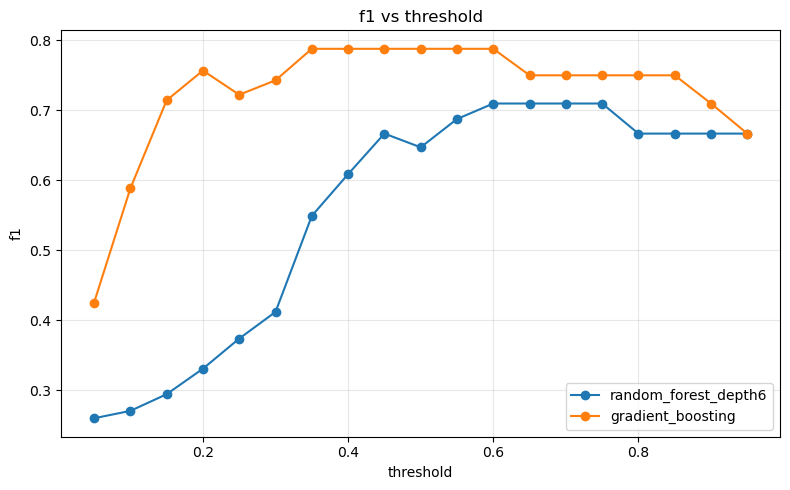

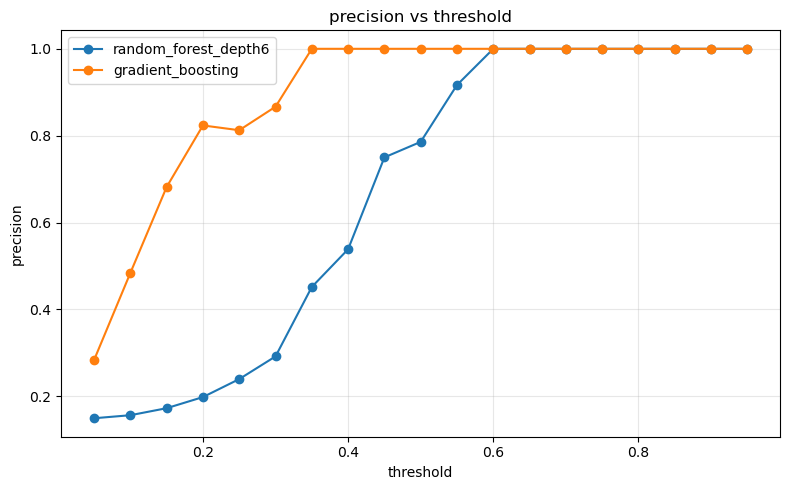

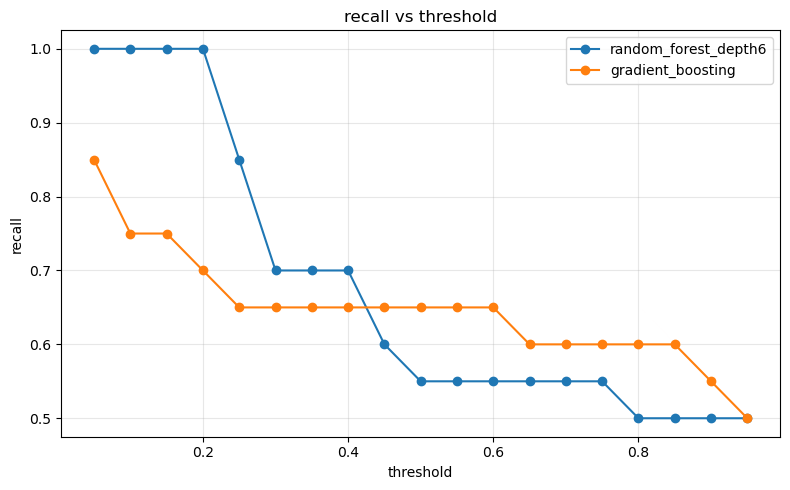

In [124]:
# plot threshold vs f1, precision, recall for rf and gb
import matplotlib.pyplot as plt

for metric in ["f1", "precision", "recall"]:
    plt.figure(figsize=(8, 5))
    for model_name in ["random_forest_depth6", "gradient_boosting"]:
        sub = threshold_results_df[threshold_results_df["model"] == model_name]
        plt.plot(sub["threshold"], sub[metric], marker="o", label=model_name)

    plt.xlabel("threshold")
    plt.ylabel(metric)
    plt.title(f"{metric} vs threshold")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

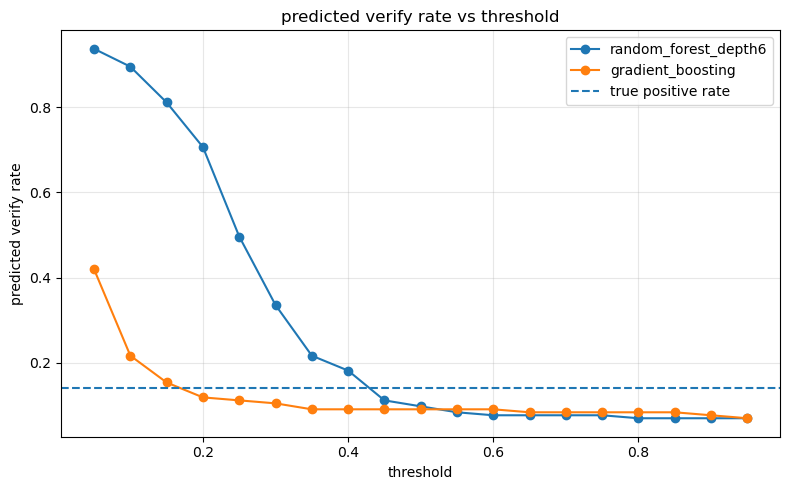

In [125]:
# plot threshold vs predicted verify rate for rf and gb
plt.figure(figsize=(8, 5))
for model_name in ["random_forest_depth6", "gradient_boosting"]:
    sub = threshold_results_df[threshold_results_df["model"] == model_name]
    plt.plot(sub["threshold"], sub["pred_verify_rate"], marker="o", label=model_name)

plt.axhline(y_test.mean(), linestyle="--", label="true positive rate")
plt.xlabel("threshold")
plt.ylabel("predicted verify rate")
plt.title("predicted verify rate vs threshold")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

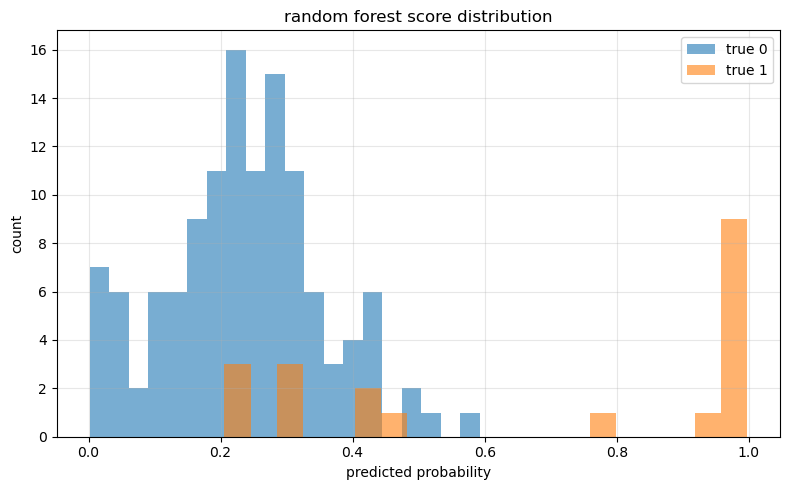

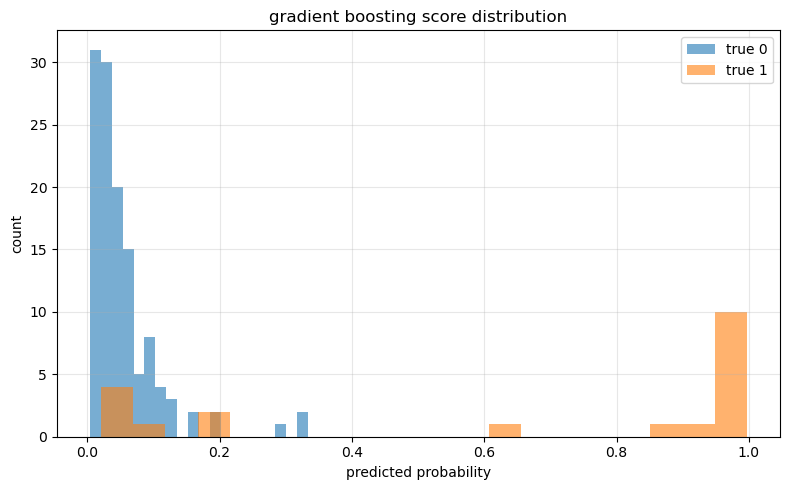

In [126]:
# plot probability distributions for rf and gb by true class
rf_scores = rf.predict_proba(X_test)[:, 1]
gb_scores = gb.predict_proba(X_test)[:, 1]

score_plot_df = pd.DataFrame({
    "y_true": y_test.values,
    "rf_score": rf_scores,
    "gb_score": gb_scores,
})

for score_col, title in [
    ("rf_score", "random forest score distribution"),
    ("gb_score", "gradient boosting score distribution"),
]:
    plt.figure(figsize=(8, 5))
    plt.hist(score_plot_df.loc[score_plot_df["y_true"] == 0, score_col], bins=20, alpha=0.6, label="true 0")
    plt.hist(score_plot_df.loc[score_plot_df["y_true"] == 1, score_col], bins=20, alpha=0.6, label="true 1")
    plt.xlabel("predicted probability")
    plt.ylabel("count")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()